# LLM11: Model Training Pipeline

## Lab Overview

This lab implements a complete LLM training pipeline, covering data collation, loss functions, training loops, and evaluation. 

**Topics Covered:**
- **Input Side**: Data preparation, batch processing strategies (Dataset / DataLoader / collate_fn)
- **Output Side**: Loss functions — autoregressive cross entropy, label shifting, prompt masking
- **Training Execution**: AdamW optimizer, learning rate scheduling, gradient accumulation, mixed precision (AMP)
- **Evaluation & Monitoring**: Perplexity, loss curves, checkpoint management
- **HuggingFace Trainer**: Quick integration for production training

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (e.g., AI Max+ 395, AI Max 390)

#### Software Environment

OS: Ubuntu 24.04.3 LTS \
Install [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=…). After installing AUP Learning Cloud, you will have a ROCm and PyTorch environment that is compatible with this notebook.
## Goals

By the end of this lab, you will be able to:

1. **Build Collate Functions**: Implement batch padding, attention masks, and label masking (-100).
2. **Understand Loss Functions**: Implement autoregressive cross entropy with label shifting and prompt masking.
3. **Write Training Loops**: Build complete loops with gradient accumulation, clipping, and AMP.
4. **Configure Optimizers**: Set up AdamW with proper weight decay and learning rate scheduling.
5. **Evaluate and Monitor**: Track loss, perplexity, and visualize training progress.
6. **Use HuggingFace Trainer**: Integrate with Trainer for production-ready training.

---


## 1. Environment Setup

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset, load_dataset
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup,
)

try:
    plt.style.use("seaborn-v0_8")
except OSError:
    plt.style.use("ggplot")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

torch.manual_seed(42)
np.random.seed(42)

2026-02-27 03:36:10.599800: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda
PyTorch version: 2.6.0+gitdbfe118
GPU: AMD Radeon Graphics
GPU Memory: 12.4 GB


In [2]:
# Prepare tokenizer and sample data for the training pipeline
tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load and tokenize a sample dataset
try:
    raw_ds = load_dataset("yahma/alpaca-cleaned", split="train[:200]")
except Exception:
    raw_ds = Dataset.from_dict({
        "instruction": ["Explain AI", "Write code"] * 100,
        "input": [""] * 200,
        "output": ["AI is...", "def foo(): pass"] * 100,
    })

def format_and_tokenize(examples):
    texts = []
    for inst, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        prompt = inst.strip()
        if inp:
            prompt += "\n" + inp.strip()
        texts.append(f"### Instruction:\n{prompt}\n\n### Response:\n{out.strip()}")

    tokenized = tokenizer(texts, truncation=True, max_length=256, padding=False)
    tokenized["labels"] = [ids.copy() for ids in tokenized["input_ids"]]
    return tokenized

tokenized_ds = raw_ds.map(format_and_tokenize, batched=True, remove_columns=raw_ds.column_names)
split = tokenized_ds.train_test_split(test_size=0.1, seed=42)
train_ds, val_ds = split["train"], split["test"]
print(f"Train: {len(train_ds)} samples, Val: {len(val_ds)} samples")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Train: 180 samples, Val: 20 samples


## 2. Collate Functions for Batch Processing

The **collate function** is the bridge between individual tokenized samples and GPU-ready batches. It handles:

1. **Padding**: Align variable-length sequences to the same length
2. **Attention masks**: Mark real tokens (1) vs padding (0)
3. **Label masking**: Set padded positions to `-100` so they're ignored by cross-entropy loss
4. **Tensor stacking**: Convert lists to batch tensors

### Design Pattern
```python
def collate_fn(batch, pad_id, label_pad_id=-100):
    input_ids = pad_sequence([...], padding_value=pad_id)
    labels    = pad_sequence([...], padding_value=-100)  # ignore in loss
    attention  = pad_sequence([...], padding_value=0)     # ignore in attention
    return {"input_ids": ..., "labels": ..., "attention_mask": ...}
```

### Why `-100` for Labels?
PyTorch's `CrossEntropyLoss` uses `ignore_index=-100` by default. Any label position set to `-100` is excluded from loss computation.

In [3]:
def causal_lm_collate(batch, pad_id, label_pad_id=-100):
    """Collate function for causal language modeling.

    Handles:
    - Variable-length sequence padding
    - Attention mask generation
    - Label padding with ignore_index=-100
    """
    input_ids = [torch.tensor(item["input_ids"]) for item in batch]
    labels = [torch.tensor(item["labels"]) for item in batch]
    attention = [torch.tensor(item["attention_mask"]) for item in batch]

    padded_input = pad_sequence(input_ids, batch_first=True, padding_value=pad_id)
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=label_pad_id)
    padded_attention = pad_sequence(attention, batch_first=True, padding_value=0)

    return {
        "input_ids": padded_input,
        "labels": padded_labels,
        "attention_mask": padded_attention,
    }


# Demonstrate collation
sample_batch = [train_ds[i] for i in range(4)]
original_lengths = [len(s["input_ids"]) for s in sample_batch]
print(f"Original lengths: {original_lengths}")

collated = causal_lm_collate(sample_batch, pad_id=tokenizer.pad_token_id)
print(f"\nCollated shapes:")
for key, tensor in collated.items():
    print(f"  {key}: {tensor.shape}")

# Verify padding and masking
print(f"\nAttention mask sums (should match original lengths):")
for i, length in enumerate(original_lengths):
    mask_sum = collated["attention_mask"][i].sum().item()
    label_valid = (collated["labels"][i] != -100).sum().item()
    print(f"  Sample {i}: original={length}, mask_sum={int(mask_sum)}, valid_labels={label_valid}")

Original lengths: [107, 37, 256, 256]

Collated shapes:
  input_ids: torch.Size([4, 256])
  labels: torch.Size([4, 256])
  attention_mask: torch.Size([4, 256])

Attention mask sums (should match original lengths):
  Sample 0: original=107, mask_sum=107, valid_labels=107
  Sample 1: original=37, mask_sum=37, valid_labels=37
  Sample 2: original=256, mask_sum=256, valid_labels=256
  Sample 3: original=256, mask_sum=256, valid_labels=256


In [4]:
# Create DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda batch: causal_lm_collate(batch, pad_id=tokenizer.pad_token_id),
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    collate_fn=lambda batch: causal_lm_collate(batch, pad_id=tokenizer.pad_token_id),
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# Inspect a training batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
for key, tensor in batch.items():
    print(f"  {key}: {tensor.shape}, dtype={tensor.dtype}")

Train batches: 45
Val batches:   5

Batch shapes:
  input_ids: torch.Size([4, 207]), dtype=torch.int64
  labels: torch.Size([4, 207]), dtype=torch.int64
  attention_mask: torch.Size([4, 207]), dtype=torch.int64


## 3. Loss Functions for Language Models

### Autoregressive Cross Entropy

The core training objective: predict the next token given all previous tokens.

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log P(x_t \mid x_{<t})$$

### Why Labels Are Right-Shifted

The model's output at position $t$ predicts the token at position $t+1$:
- `logits[t]` → predicts `input_ids[t+1]`
- So `labels[t] = input_ids[t+1]` (right-shifted by 1)

In HuggingFace models, this shift happens **internally** in the loss computation:
```python
# Inside HF model forward():
shift_logits = logits[..., :-1, :]
shift_labels = labels[..., 1:]
loss = CrossEntropyLoss()(shift_logits, shift_labels)
```

### Instruction Tuning: Prompt Masking
For SFT, we often want to compute loss **only on the response**, not the prompt:
```python
# Set prompt positions to -100 (ignored by CrossEntropyLoss)
labels[:prompt_length] = -100
```

In [5]:
# Demonstrate label shifting and loss computation
print("=== Label Shifting Demonstration ===")

# Simulate a small vocabulary (size=10) example
vocab_size = 10
seq_len = 6

# Input: token ids
input_ids = torch.tensor([2, 5, 3, 7, 1, 4])  # [BOS, tok, tok, tok, tok, EOS]
print(f"Input IDs: {input_ids.tolist()}")

# Labels for causal LM: same as input (shift happens internally)
labels = input_ids.clone()
print(f"Labels:    {labels.tolist()}")

# Manual shift to show what the model actually computes
shift_logits_positions = list(range(seq_len - 1))  # [0, 1, 2, 3, 4]
shift_labels = labels[1:]  # [5, 3, 7, 1, 4]
print(f"\nAfter internal shift:")
print(f"  Logit positions: {shift_logits_positions}")
print(f"  Target labels:   {shift_labels.tolist()}")
print(f"  Meaning: position 0 predicts token {shift_labels[0].item()}, "
      f"position 1 predicts token {shift_labels[1].item()}, ...")

# Simulated logits (random)
logits = torch.randn(seq_len, vocab_size)
shift_logits = logits[:-1]  # (5, 10)

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(shift_logits, shift_labels)
perplexity = math.exp(loss.item())
print(f"\nCross-entropy loss: {loss.item():.4f}")
print(f"Perplexity: {perplexity:.2f} (random baseline ≈ {vocab_size})")

=== Label Shifting Demonstration ===
Input IDs: [2, 5, 3, 7, 1, 4]
Labels:    [2, 5, 3, 7, 1, 4]

After internal shift:
  Logit positions: [0, 1, 2, 3, 4]
  Target labels:   [5, 3, 7, 1, 4]
  Meaning: position 0 predicts token 5, position 1 predicts token 3, ...

Cross-entropy loss: 2.6247
Perplexity: 13.80 (random baseline ≈ 10)


In [6]:
# Demonstrate prompt masking for instruction tuning
print("=== Prompt Masking for SFT ===")

# Example: instruction + response
instruction = "What is the capital of France?"
response = "The capital of France is Paris."
full_text = f"### Instruction:\n{instruction}\n\n### Response:\n{response}"

# Tokenize
full_tokens = tokenizer(full_text, return_tensors="pt")
full_ids = full_tokens["input_ids"][0]

# Find where the response starts
prompt_text = f"### Instruction:\n{instruction}\n\n### Response:\n"
prompt_tokens = tokenizer(prompt_text)["input_ids"]
prompt_length = len(prompt_tokens)

print(f"Full sequence length: {len(full_ids)}")
print(f"Prompt length: {prompt_length}")
print(f"Response length: {len(full_ids) - prompt_length}")

# Create labels with prompt masked
labels = full_ids.clone()
labels[:prompt_length] = -100  # Mask prompt — don't compute loss on it

print(f"\nLabels (first {prompt_length} positions masked to -100):")
print(f"  Prompt labels:   {labels[:prompt_length].tolist()[:5]}... (all -100)")
print(f"  Response labels:  {labels[prompt_length:].tolist()}")

# Loss is only computed on non-(-100) positions
valid_positions = (labels != -100).sum().item()
print(f"\nLoss computed on {valid_positions} / {len(labels)} positions")
print(f"This means the model only learns to generate the response, not memorize the prompt.")

=== Prompt Masking for SFT ===
Full sequence length: 24
Prompt length: 17
Response length: 7

Labels (first 17 positions masked to -100):
  Prompt labels:   [-100, -100, -100, -100, -100]... (all -100)
  Response labels:  [464, 3139, 286, 4881, 318, 6342, 13]

Loss computed on 7 / 24 positions
This means the model only learns to generate the response, not memorize the prompt.


## 4. Training Configuration and Optimizer

### AdamW Optimizer
The standard optimizer for LLM training. Key settings:
- **Weight decay**: Applied to all parameters except bias and LayerNorm (decoupled from gradient updates)
- **β1, β2**: Momentum parameters (typically 0.9, 0.999)

### Learning Rate Scheduling
- **Warmup**: Gradually increase LR to avoid early divergence
- **Cosine decay**: Smoothly decrease LR after warmup

### Gradient Accumulation
Simulates larger batch sizes with limited GPU memory:
- Effective batch = `batch_size × gradient_accumulation_steps`
- Accumulate gradients for N mini-batches before optimizer step

### Mixed Precision (AMP)
Use FP16/BF16 for forward/backward, FP32 for optimizer:
- ~2x memory reduction
- ~1.5-2x throughput improvement
- `GradScaler` prevents underflow in FP16 gradients

In [7]:
# Training configuration
class TrainingConfig:
    """Hyperparameters for training."""
    batch_size: int = 4
    gradient_accumulation_steps: int = 4
    max_epochs: int = 3
    learning_rate: float = 5e-5
    weight_decay: float = 0.01
    max_grad_norm: float = 1.0
    warmup_steps: int = 50
    eval_steps: int = 50
    logging_steps: int = 10
    fp16: bool = torch.cuda.is_available()


config = TrainingConfig()
effective_batch = config.batch_size * config.gradient_accumulation_steps
print(f"Training config:")
print(f"  Batch size: {config.batch_size}")
print(f"  Gradient accumulation: {config.gradient_accumulation_steps}")
print(f"  Effective batch size: {effective_batch}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Mixed precision: {config.fp16}")

Training config:
  Batch size: 4
  Gradient accumulation: 4
  Effective batch size: 16
  Learning rate: 5e-05
  Mixed precision: True


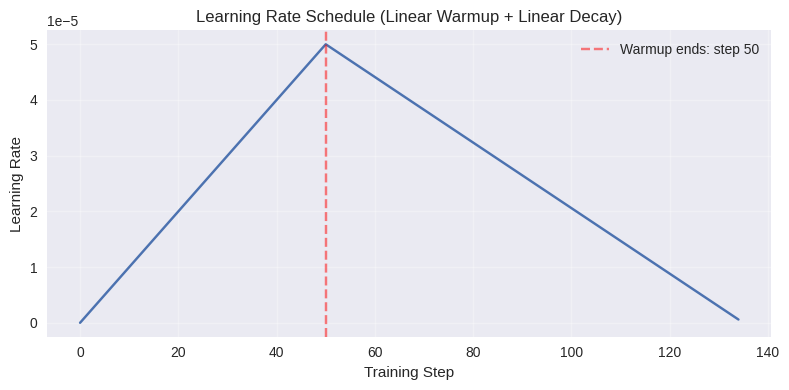

Total training steps: 135


In [8]:
# Setup optimizer with separate weight decay groups
def setup_optimizer(model, config):
    """Create AdamW optimizer with proper weight decay grouping.

    Bias and LayerNorm parameters should NOT have weight decay.
    """
    no_decay = ["bias", "LayerNorm.weight", "layer_norm.weight"]

    param_groups = [
        {
            "params": [
                p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay) and p.requires_grad
            ],
            "weight_decay": config.weight_decay,
        },
        {
            "params": [
                p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay) and p.requires_grad
            ],
            "weight_decay": 0.0,
        },
    ]

    optimizer = AdamW(param_groups, lr=config.learning_rate)
    return optimizer


# Visualize learning rate schedule
def plot_lr_schedule(warmup_steps, total_steps, lr):
    """Visualize the learning rate schedule."""
    # Create a dummy optimizer and scheduler
    dummy_param = torch.nn.Parameter(torch.zeros(1))
    dummy_opt = AdamW([dummy_param], lr=lr)
    scheduler = get_linear_schedule_with_warmup(
        dummy_opt, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    lrs = []
    for _ in range(total_steps):
        lrs.append(scheduler.get_last_lr()[0])
        dummy_opt.step()
        scheduler.step()

    plt.figure(figsize=(8, 4))
    plt.plot(lrs)
    plt.title("Learning Rate Schedule (Linear Warmup + Linear Decay)")
    plt.xlabel("Training Step")
    plt.ylabel("Learning Rate")
    plt.axvline(warmup_steps, color="red", linestyle="--", alpha=0.5, label=f"Warmup ends: step {warmup_steps}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


total_steps = len(train_loader) * config.max_epochs
plot_lr_schedule(config.warmup_steps, total_steps, config.learning_rate)
print(f"Total training steps: {total_steps}")

## 5. Hand-Written Training Loop

A complete training loop with:
- Forward pass → loss computation
- Backward pass → gradient computation
- Gradient accumulation → simulate larger batches
- Gradient clipping → prevent exploding gradients
- Mixed precision (AMP) → memory and speed optimization
- Evaluation → validation loss and perplexity

```python
# Core training step pattern
for step, batch in enumerate(dataloader):
    with autocast():                          # Mixed precision
        loss = model(**batch).loss
    scaler.scale(loss).backward()              # Scaled backward
    if (step + 1) % grad_accumulation == 0:
        scaler.unscale_(optimizer)
        clip_grad_norm_(model.parameters(), max_norm)
        scaler.step(optimizer)                 # Optimizer step
        scaler.update()
        optimizer.zero_grad()
```

In [9]:
def train_epoch(model, dataloader, optimizer, scheduler, config, scaler=None):
    """Execute one training epoch with gradient accumulation and AMP."""
    model.train()
    total_loss = 0
    num_steps = 0
    log_losses = []

    for step, batch in enumerate(dataloader):
        # Move to device
        batch = {k: v.to(device) for k, v in batch.items()}

        # Forward pass (with optional AMP)
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(**batch)
                loss = outputs.loss / config.gradient_accumulation_steps
            scaler.scale(loss).backward()
        else:
            outputs = model(**batch)
            loss = outputs.loss / config.gradient_accumulation_steps
            loss.backward()

        total_loss += loss.item() * config.gradient_accumulation_steps
        num_steps += 1

        # Optimizer step after accumulation
        if (step + 1) % config.gradient_accumulation_steps == 0:
            if scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad()

            # Logging
            avg_loss = total_loss / num_steps
            log_losses.append(avg_loss)

            if len(log_losses) % config.logging_steps == 0:
                lr = scheduler.get_last_lr()[0]
                print(f"  Step {len(log_losses)}: loss={avg_loss:.4f}, lr={lr:.2e}")

    return total_loss / max(num_steps, 1), log_losses


@torch.no_grad()
def evaluate(model, dataloader, max_batches=50):
    """Evaluate model on validation data."""
    model.eval()
    total_loss = 0
    num_batches = 0

    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()
        num_batches += 1
        if num_batches >= max_batches:
            break

    avg_loss = total_loss / max(num_batches, 1)
    perplexity = math.exp(avg_loss) if avg_loss < 20 else float("inf")
    return avg_loss, perplexity

In [10]:
# Complete training loop
def run_training(model, train_loader, val_loader, config):
    """Run the complete training pipeline."""
    model.to(device)

    # Setup optimizer and scheduler
    optimizer = setup_optimizer(model, config)
    total_steps = len(train_loader) * config.max_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=config.warmup_steps,
        num_training_steps=total_steps,
    )

    # Setup AMP
    scaler = None
    if config.fp16 and torch.cuda.is_available():
        scaler = torch.cuda.amp.GradScaler()
        print("Mixed precision (AMP) enabled")

    # Metrics
    metrics = {
        "train_losses": [],
        "eval_losses": [],
        "eval_ppls": [],
        "learning_rates": [],
    }

    param_count = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel: {param_count:,} total params, {trainable:,} trainable")
    print(f"Training for {config.max_epochs} epochs, {total_steps} steps")
    print(f"Effective batch size: {config.batch_size * config.gradient_accumulation_steps}")
    print("=" * 60)

    start_time = time.time()
    best_eval_loss = float("inf")

    for epoch in range(config.max_epochs):
        print(f"\nEpoch {epoch + 1}/{config.max_epochs}")
        epoch_start = time.time()

        # Train
        train_loss, step_losses = train_epoch(
            model, train_loader, optimizer, scheduler, config, scaler
        )
        metrics["train_losses"].append(train_loss)

        # Evaluate
        eval_loss, eval_ppl = evaluate(model, val_loader)
        metrics["eval_losses"].append(eval_loss)
        metrics["eval_ppls"].append(eval_ppl)

        # Track best
        improved = "*" if eval_loss < best_eval_loss else ""
        if eval_loss < best_eval_loss:
            best_eval_loss = eval_loss

        epoch_time = time.time() - epoch_start
        print(f"  Train loss: {train_loss:.4f} | Eval loss: {eval_loss:.4f} "
              f"| PPL: {eval_ppl:.2f} | Time: {epoch_time:.1f}s {improved}")

    total_time = time.time() - start_time
    print(f"\n{'=' * 60}")
    print(f"Training complete in {total_time:.1f}s")
    print(f"Best eval loss: {best_eval_loss:.4f}")

    return metrics


# Run training (using GPT-2 small for demonstration)
print("Loading GPT-2 for training demonstration...")
gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2")
gpt2_model.config.pad_token_id = tokenizer.pad_token_id

# Use small config for quick demo
config.max_epochs = 2
config.logging_steps = 5
config.gradient_accumulation_steps = 2

metrics = run_training(gpt2_model, train_loader, val_loader, config)

Loading GPT-2 for training demonstration...


/tmp/ipykernel_857/3336765353.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_857/2498539591.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Mixed precision (AMP) enabled

Model: 124,439,808 total params, 124,439,808 trainable
Training for 2 epochs, 90 steps
Effective batch size: 8

Epoch 1/2


/opt/conda/envs/py_3.12/lib/python3.12/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Using AOTriton backend for Efficient Attention forward... (Triggered internally at /var/lib/jenkins/pytorch/aten/src/ATen/native/transformers/hip/attention.hip:1180.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
/opt/conda/envs/py_3.12/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Using AOTriton backend for Efficient Attention backward... (Triggered internally at /var/lib/jenkins/pytorch/aten/src/ATen/native/transformers/hip/attention_backward.hip:463.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Step 5: loss=3.1576, lr=5.00e-06
  Step 10: loss=3.1696, lr=1.00e-05
  Step 15: loss=3.0879, lr=1.50e-05
  Step 20: loss=3.0331, lr=2.00e-05
  Train loss: 2.9958 | Eval loss: 2.5505 | PPL: 12.81 | Time: 18.4s *

Epoch 2/2
  Step 5: loss=2.6184, lr=2.70e-05
  Step 10: loss=2.5314, lr=3.20e-05
  Step 15: loss=2.5155, lr=3.70e-05
  Step 20: loss=2.4881, lr=4.20e-05
  Train loss: 2.4600 | Eval loss: 2.3285 | PPL: 10.26 | Time: 16.4s *

Training complete in 34.8s
Best eval loss: 2.3285


## 6. Training Visualization and Analysis

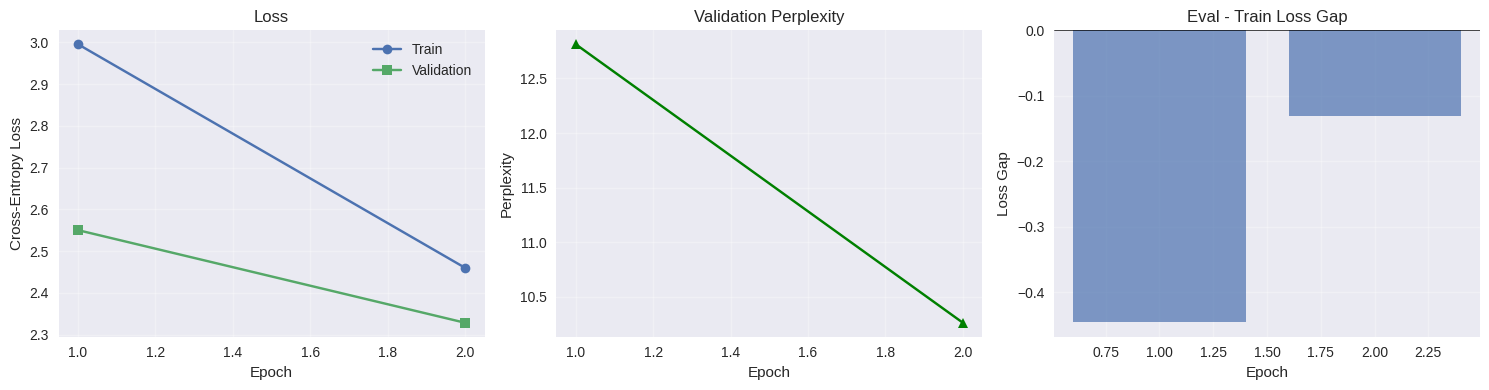

In [11]:
def plot_training_metrics(metrics):
    """Visualize training progress."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    epochs = range(1, len(metrics["train_losses"]) + 1)

    # Training vs Validation Loss
    axes[0].plot(epochs, metrics["train_losses"], "o-", label="Train")
    axes[0].plot(epochs, metrics["eval_losses"], "s-", label="Validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Perplexity
    axes[1].plot(epochs, metrics["eval_ppls"], "^-", color="green")
    axes[1].set_title("Validation Perplexity")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Perplexity")
    axes[1].grid(True, alpha=0.3)

    # Loss gap (overfitting indicator)
    gaps = [e - t for t, e in zip(metrics["train_losses"], metrics["eval_losses"])]
    axes[2].bar(epochs, gaps, alpha=0.7)
    axes[2].set_title("Eval - Train Loss Gap")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss Gap")
    axes[2].axhline(0, color="black", linewidth=0.5)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


if metrics["train_losses"]:
    plot_training_metrics(metrics)

## 7. HuggingFace Trainer Integration

The HuggingFace `Trainer` class encapsulates the entire training pipeline:
- Optimizer & scheduler setup
- Gradient accumulation & clipping
- Mixed precision
- Logging (TensorBoard, W&B)
- Checkpoint saving & loading
- Distributed training support

### Trainer vs Hand-Written Loop
| Feature | Trainer | Hand-Written |
|---------|---------|-------------|
| Setup time | Minutes | Hours |
| Customization | Callbacks | Full control |
| Distributed | Built-in | Manual |
| Debugging | Harder | Easier |
| Best for | Production | Research |

In [12]:
# HuggingFace Trainer example
import tempfile

trainer_model = AutoModelForCausalLM.from_pretrained("gpt2")
trainer_model.config.pad_token_id = tokenizer.pad_token_id

with tempfile.TemporaryDirectory() as tmpdir:
    training_args = TrainingArguments(
        output_dir=tmpdir,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        learning_rate=5e-5,
        warmup_steps=10,
        num_train_epochs=1,
        logging_steps=10,
        save_strategy="no",
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer = Trainer(
        model=trainer_model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=lambda batch: causal_lm_collate(
            batch, pad_id=tokenizer.pad_token_id
        ),
    )

    print("Starting Trainer...")
    train_result = trainer.train()

    print(f"\nTrainer results:")
    print(f"  Training loss: {train_result.training_loss:.4f}")
    print(f"  Training steps: {train_result.global_step}")

    # Evaluation — strip Jupyter NotebookProgressCallback only here so training keeps the progress UI,
    # while avoiding RuntimeError: on_train_begin must be called before on_evaluate
    try:
        from transformers.utils.notebook import NotebookProgressCallback

        trainer.remove_callback(NotebookProgressCallback)
    except (ValueError, ImportError, AttributeError):
        pass

    eval_result = trainer.evaluate()
    print(f"  Eval loss: {eval_result['eval_loss']:.4f}")
    print(f"  Eval PPL: {math.exp(eval_result['eval_loss']):.2f}")

Starting Trainer...


Step,Training Loss
10,3.032700
20,2.568700



Trainer results:
  Training loss: 2.7790
  Training steps: 23


  Eval loss: 2.3987
  Eval PPL: 11.01


## 8. LLaMA Factory Overview

For production-scale fine-tuning, [LLaMA Factory](https://github.com/hiyouga/LLaMA-Factory) provides an all-in-one toolkit:

### Quick Start
```bash
pip install llamafactory[torch]

llamafactory train --config configs/lora_sft.yaml --flash_attn --gradient_checkpointing
```

### Example Configuration (YAML)
```yaml
stage: sft
model_name_or_path: meta-llama/Llama-3-8B-Instruct
finetuning_type: lora
template: llama3
train_file: data/alpaca.jsonl
output_dir: output/lora-sft
per_device_train_batch_size: 1
gradient_accumulation_steps: 8
learning_rate: 2e-4
lr_scheduler_type: cosine
num_train_epochs: 3
lora_target: q_proj,v_proj
bnb_4bit_quant_type: nf4        # QLoRA
```

### Data Format (JSONL)
```json
{"instruction": "写一段自我介绍", "input": "", "output": "大家好..."}
```
or with `messages`:
```json
{"messages": [{"role": "user", "content": "介绍课程"}, {"role": "assistant", "content": "本课程..."}]}
```

### Key Advantages
- Supports LoRA, QLoRA, full fine-tuning, DPO, RLHF
- Built-in DeepSpeed ZeRO and FlashAttention support
- Web UI for configuration and monitoring
- Compatible with LLaMA, Qwen, Mistral, and many other models

## Conclusions

### What We Covered (LLM11)

| Topic | Key Concepts |
|-------|--------------|
| **Collate Functions** | `pad_sequence`, attention masks, label masking (`-100`), `DataLoader` integration |
| **Loss Functions** | Autoregressive cross entropy, label right-shifting, prompt masking for SFT |
| **Training Loop** | Forward/backward, gradient accumulation, gradient clipping, AMP (`GradScaler`) |
| **Optimizer & Scheduler** | AdamW with weight decay groups, linear warmup + decay |
| **Evaluation** | Validation loss, perplexity, overfitting detection |
| **HF Trainer** | `TrainingArguments`, `Trainer`, `data_collator`, `compute_metrics` |
| **LLaMA Factory** | YAML config, LoRA/QLoRA, multi-model support |

### Key Takeaways
- The collate function is the critical bridge between preprocessed data and GPU-ready batches
- Label shifting (`labels[t] = input_ids[t+1]`) is the foundation of autoregressive training
- Prompt masking (`-100`) ensures the model only learns to generate responses, not memorize prompts
- Gradient accumulation lets you simulate large batch sizes with limited GPU memory
- HF `Trainer` is production-ready; hand-written loops give full research control

### Experiment Further
- Implement a collate function with dynamic padding (pad to nearest multiple of 8)
- Add prompt masking to the collate function and compare training behavior
- Experiment with different learning rate schedules (cosine vs polynomial decay)
- Try gradient checkpointing to reduce memory usage for larger models
- Use LLaMA Factory to fine-tune a model with LoRA and compare with your hand-written loop

---

Copyright (C) 2025 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT
